Classificazione k-NN

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
data = load_iris()
X = data.data
y = data.target

display(pd.DataFrame(X, columns=data.feature_names))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [3]:
display(pd.DataFrame(y, columns=["target"]))

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
k_range = range(1, 21)
error_rate = []

# prendiamo solo i numeri dispari per evitare ambiguità
k_range_odd = [k for k in k_range if k % 2 != 0]

for k in k_range_odd:
    knn_clf = KNeighborsClassifier(n_neighbors=k)
    knn_clf.fit(X_scaled, y)
    y_pred = knn_clf.predict(X_scaled)
    error_rate.append(1- accuracy_score(y, y_pred))


In [6]:
print(len(error_rate))

10


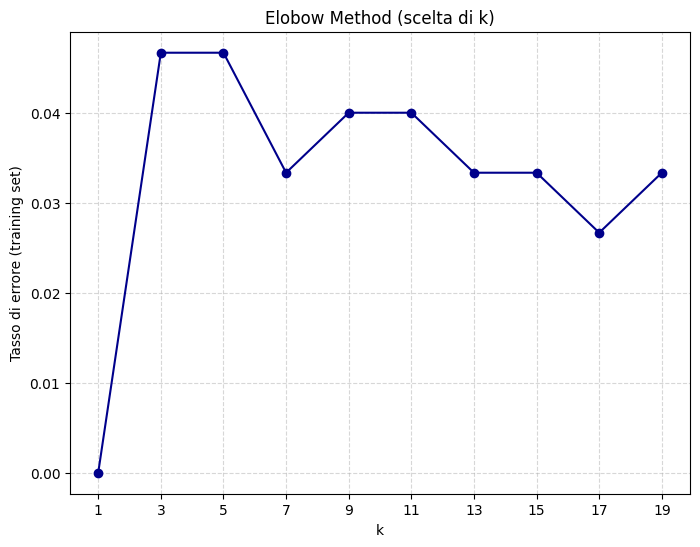

In [7]:
plt.figure(figsize=(8,6))
plt.plot(k_range_odd, error_rate, marker="o", linestyle="-", color="darkblue")
plt.title("Elobow Method (scelta di k)")
plt.xlabel("k")
plt.ylabel("Tasso di errore (training set)")
plt.xticks(k_range_odd)
plt.grid(True, linestyle="--", alpha = 0.5)
plt.show()

In [8]:
best_k = 3
knn_final = KNeighborsClassifier(n_neighbors=best_k)
feature_0 = 0
feature_1 = 1

# per la rappresentazione grafica facciamo un dataframe 2d selezionando solo due feature
X_2d = X_scaled[:, [feature_0, feature_1]]

knn_final.fit(X_2d, y)
y_pred = knn_final.predict(X_2d)

In [9]:
# impostiamo i valori del piano cartesiano come valori max e min delle due feature
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5

# griglia rettangolare con punti equispaziati
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# creazione dello spazio con le coordinate appiattite
Z = knn_final.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

C:\Users\chian\AppData\Local\Temp\ipykernel_14344\143178453.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


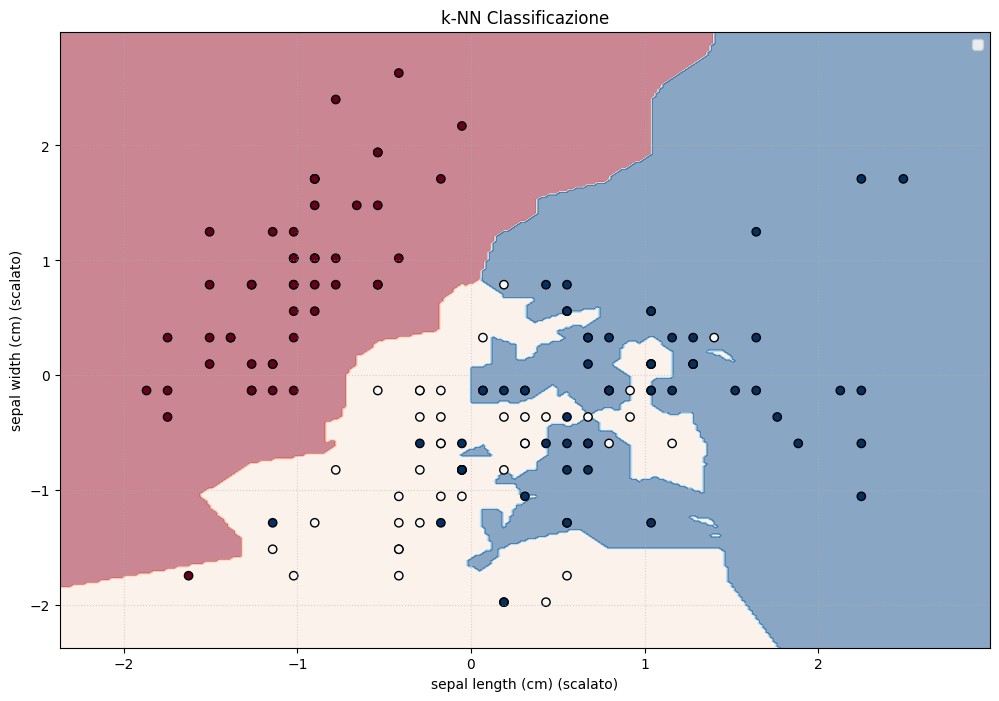

In [10]:
plt.figure(figsize=(12,8))
plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.RdBu)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolors="k", cmap=plt.cm.RdBu)
plt.title("k-NN Classificazione")
plt.xlabel(f"{data.feature_names[feature_0]} (scalato)")
plt.ylabel(f"{data.feature_names[feature_1]} (scalato)")

plt.xlim(xx.min(), xx.max())
plt.ylim(xx.min(), xx.max())

plt.xticks()
plt.yticks()
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend()
plt.show()

In [11]:
# misuriamo l'accuratezza

tot_samples = len(y)

correct_arr = (y_pred == y)
correct_count = np.sum(correct_arr)
incorrect_count = tot_samples - correct_count
print(f"TOT:\t{tot_samples}")
print(f"Correct:\t{correct_count}")
print(f"Incorrect:\t{incorrect_count}")

accuracy = correct_count / tot_samples
print(f"Accuracy:\t{accuracy*100:.2f}%")

TOT:	150
Correct:	127
Incorrect:	23
Accuracy:	84.67%
